# Rough Bergomi PDE via RWNN

This notebook demonstrates the RWNN-PDE algorithm applied to the **rough Bergomi
model**, pricing a European call option. We compare the PDE price at $t=0$ against
a Monte Carlo benchmark.

**Reference:** Jacquier & Zuric (2023), *Random neural networks for rough volatility*,
[arXiv:2305.01035](https://arxiv.org/abs/2305.01035)

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from rwnn_pde import rBergomiParameters, rBergomiTrainer, roughBergomi
from rwnn_pde.payoffs import vanilla_payoff

plt.style.use('seaborn-v0_8-paper')

## 1. Parameters

The rough Bergomi model is parameterised by the Hurst index $H$ (roughness),
the initial forward variance $\xi_0$, the vol-of-vol $\eta$, and the
correlation $\rho$ between price and variance.

In [2]:
params = rBergomiParameters(
    S0=1.0,
    T=1.0,
    H=0.1,        # rough volatility (H < 0.5)
    r=0.01,
    rho=-0.7,     # leverage effect
    xi=0.235**2,  # initial forward variance
    eta=1.9,      # vol-of-vol
    K=1.0,        # at-the-money
    opt_type='c',
    n_hidden_nodes=100,
    connectivity=1.0,
    input_scaling=0.25,
    weight_compact_radius=0.5,
)

print(f'Hurst index H = {params.H}  →  roughness parameter a = H - 0.5 = {params.H - 0.5}')

Hurst index H = 0.1  →  roughness parameter a = H - 0.5 = -0.4


## 2. Simulate Paths

In [3]:
model = roughBergomi(params, N_samples=50_000, n_timesteps=21)
print(f'Price path shape:    {model.S.shape}  (N_samples × (n_timesteps+1) × 1)')
print(f'Variance path shape: {model.V.shape}')

func:'simulate_paths' took: 0.4227 sec
Price path shape:    (50000, 22, 1)  (N_samples × (n_timesteps+1) × 1)
Variance path shape: (50000, 22, 1)


## 3. Solve the PDE via Backward Induction

The rBergomi trainer uses two coupled reservoirs (ξ and θ) per time step,
as described in Section 3 of the paper.

In [4]:
trainer = rBergomiTrainer(model)
Y = trainer.fit(alpha=0.1, seed=0)
print(f'Solution array shape: {Y.shape}  (N_samples × (n_timesteps+1) × 1)')

func:'fit' took: 9.8784 sec
Solution array shape: (50000, 22, 1)  (N_samples × (n_timesteps+1) × 1)


## 4. Results

In [5]:
theo_price = model.call_price(N_samples=8 * 10**5)
mc_price   = vanilla_payoff(S=model.S[:, -1, :], K=params.K).mean(0)
pde_price  = Y[:, 0, :].mean(0)

print(f'MC benchmark (800k paths):         {theo_price:.6f}')
print(f'MC price (terminal payoff mean):   {mc_price[0]:.6f}')
print(f'PDE price (t=0, path mean):        {pde_price[0]:.6f}')
print(f'MSE vs benchmark: {((theo_price - pde_price) ** 2).mean():.6e}')

func:'simulate_paths' took: 18.6731 sec
MC benchmark (800k paths):         0.084436
MC price (terminal payoff mean):   0.084202
PDE price (t=0, path mean):        0.087806
MSE vs benchmark: 1.135293e-05


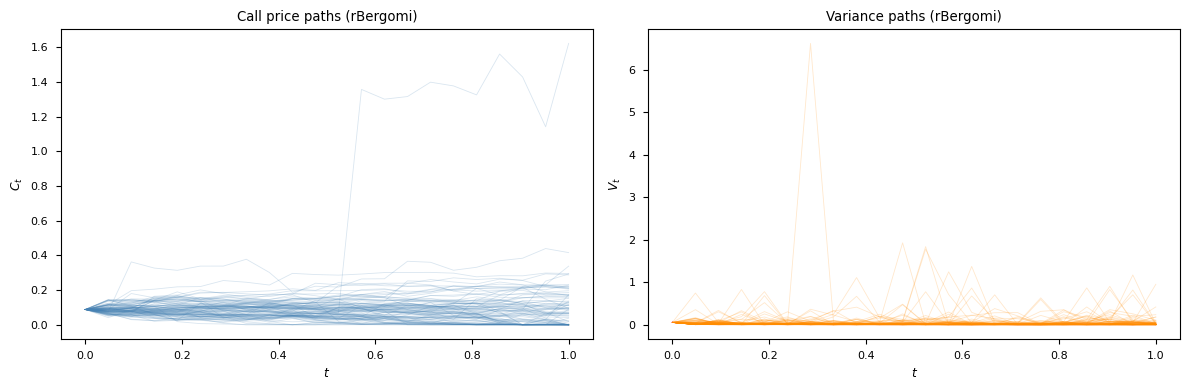

In [6]:
idx = np.random.choice(Y.shape[0], 100, replace=False)
t   = model.time_grid.T

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(t, Y[idx, :, 0].T, alpha=0.2, lw=0.6, color='steelblue')
axes[0].set_xlabel('$t$')
axes[0].set_ylabel('$C_t$')
axes[0].set_title('Call price paths (rBergomi)')

axes[1].plot(t, model.V[idx, :, 0].T, alpha=0.2, lw=0.6, color='darkorange')
axes[1].set_xlabel('$t$')
axes[1].set_ylabel('$V_t$')
axes[1].set_title('Variance paths (rBergomi)')

plt.tight_layout()
plt.show()